# Imports, Mount Drive, Global Paths

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 1

In [3]:
from google.colab import drive
drive.mount('/users/')

Mounted at /users/


# PATHS & DATASET CONFIG

In [4]:
BASE_DIR = "/users/"
PREPROC_DIR = os.path.join(BASE_DIR, "preprocessed-dataset")
MODELS_DIR = os.path.join(BASE_DIR, "Models")

FALCON_FL_RESULTS_DIR = os.path.join(MODELS_DIR, "falcon_fl_results")
FED_CLUSTER_DIR        = os.path.join(MODELS_DIR, "FedClustered")
FINAL_RESULTS_DIR      = os.path.join(MODELS_DIR, "final_results")

os.makedirs(FINAL_RESULTS_DIR, exist_ok=True)

In [5]:
def auto_find_dataset(folder_prefix: str) -> str:
    matches = [p for p in sorted(os.listdir(PREPROC_DIR)) if p.startswith(folder_prefix)]
    if not matches:
        raise ValueError(f"No folder found matching prefix: {folder_prefix} in {PREPROC_DIR}")
    return os.path.join(PREPROC_DIR, matches[0])

DATASET_PATHS = {
    "CSE_CIC_IDS2018":      auto_find_dataset("CSE_CIC_IDS2018"),
    "CIC_IIoT_2025":        auto_find_dataset("CIC_IIoT_2025"),
    "CIC_BCCC_IoMT_2024":   auto_find_dataset("CIC_BCCC_NRC_IoMT_2024"),
    "Combined":             auto_find_dataset("Combined"),
}

DATASET_ORDER = ["CSE_CIC_IDS2018", "CIC_IIoT_2025", "CIC_BCCC_IoMT_2024", "Combined"]

print("📁 Resolved DATASET_PATHS:")
for k, v in DATASET_PATHS.items():
    print(f"  - {k}: {v}")

📁 Resolved DATASET_PATHS:
  - CSE_CIC_IDS2018: /users/
  - CIC_IIoT_2025: /users/
  - CIC_BCCC_IoMT_2024: /users/
  - Combined: /users/


# DATASET SPLIT SUMMARY (TRAIN/VAL/TEST)

In [6]:
def get_latent_filenames(ds_name: str):
    if ds_name == "Combined":
        return {
            "X_train": "combined_train_latent.npy",
            "X_val":   "combined_val_latent.npy",
            "X_test":  "combined_test_latent.npy",
            "y_train": "combined_y_train.npy",
            "y_val":   "combined_y_val.npy",
            "y_test":  "combined_y_test.npy",
        }
    else:
        return {
            "X_train": "train_latent.npy",
            "X_val":   "val_latent.npy",
            "X_test":  "test_latent.npy",
            "y_train": "y_train.npy",
            "y_val":   "y_val.npy",
            "y_test":  "y_test.npy",
        }

In [7]:
def get_dataset_split_summary():
    rows = []
    for ds_name in DATASET_ORDER:
        path = DATASET_PATHS[ds_name]
        files = get_latent_filenames(ds_name)

        X_train = np.load(os.path.join(path, files["X_train"]), mmap_mode="r")
        X_val   = np.load(os.path.join(path, files["X_val"]),   mmap_mode="r")
        X_test  = np.load(os.path.join(path, files["X_test"]),  mmap_mode="r")

        y_train = np.load(os.path.join(path, files["y_train"]), mmap_mode="r")
        y_val   = np.load(os.path.join(path, files["y_val"]),   mmap_mode="r")
        y_test  = np.load(os.path.join(path, files["y_test"]),  mmap_mode="r")

        num_classes = len(np.unique(y_train))
        input_dim   = X_train.shape[1]

        rows.append({
            "dataset": ds_name,
            "input_dim": input_dim,
            "train_samples": len(X_train),
            "val_samples": len(X_val),
            "test_samples": len(X_test),
            "total_samples": len(X_train) + len(X_val) + len(X_test),
            "num_classes": num_classes,
        })

    df = pd.DataFrame(rows)
    return df

In [8]:
dataset_split_df = get_dataset_split_summary()
print("\n📊 Dataset Split Summary (train / val / test):")
display(dataset_split_df)


📊 Dataset Split Summary (train / val / test):


,dataset,input_dim,train_samples,val_samples,test_samples,total_samples,num_classes
0,CSE_CIC_IDS2018,64,6737603,1443772,1443773,9625148,15
1,CIC_IIoT_2025,64,29424,6305,6306,42035,7
2,CIC_BCCC_IoMT_2024,64,2369719,507797,507797,3385313,15
3,Combined,64,9136746,1957874,1957876,13052496,37


In [9]:
split_summary_path = os.path.join(FINAL_RESULTS_DIR, "dataset_split_summary.csv")
dataset_split_df.to_csv(split_summary_path, index=False)
print(f"💾 Saved dataset split summary to: {split_summary_path}")

💾 Saved dataset split summary to: /users/


# FEDAVG — CLASS-WISE AND DATASET-WISE SUMMARY

In [10]:
def load_fedavg_class_report_for_dataset(ds_name: str) -> pd.DataFrame:
    """Load class-level report for a dataset and standardize columns."""
    csv_path = os.path.join(FALCON_FL_RESULTS_DIR, ds_name, "class_report.csv")
    if not os.path.exists(csv_path):
        print(f"⚠️ FedAvg class_report not found for dataset {ds_name}: {csv_path}")
        return None

    df = pd.read_csv(csv_path)
    # Standardize column naming
    if "Unnamed: 0" in df.columns:
        df = df.rename(columns={"Unnamed: 0": "class_label"})
    df["dataset"] = ds_name
    return df

In [12]:
fedavg_class_dfs = []
fedavg_dataset_rows = []

for ds_name in DATASET_ORDER:
    df_cls = load_fedavg_class_report_for_dataset(ds_name)
    if df_cls is None:
        continue

    fedavg_class_dfs.append(df_cls)

    # Compute weighted metrics and approximate accuracy from class-wise metrics
    total_support = df_cls["support"].sum()
    weighted_precision = (df_cls["precision"] * df_cls["support"]).sum() / total_support
    weighted_recall    = (df_cls["recall"]    * df_cls["support"]).sum() / total_support
    weighted_f1        = (df_cls["f1-score"]  * df_cls["support"]).sum() / total_support

    # For multi-class classification:
    # Accuracy = (sum_i recall_i * support_i) / total_support == weighted recall
    estimated_accuracy = weighted_recall

    fedavg_dataset_rows.append({
        "dataset": ds_name,
        "num_classes": df_cls["class_label"].nunique(),
        "test_samples": int(total_support),
        "fedavg_weighted_precision": weighted_precision,
        "fedavg_weighted_recall": weighted_recall,
        "fedavg_weighted_f1": weighted_f1,
        "fedavg_estimated_accuracy": estimated_accuracy,
    })

In [13]:
if fedavg_class_dfs:
    fedavg_class_all = pd.concat(fedavg_class_dfs, axis=0, ignore_index=True)
else:
    fedavg_class_all = pd.DataFrame()

fedavg_dataset_summary = pd.DataFrame(fedavg_dataset_rows)

print("\n📊 FedAvg Dataset-level Summary (from class_report):")
display(fedavg_dataset_summary)

fedavg_dataset_summary_path = os.path.join(FINAL_RESULTS_DIR, "fedavg_dataset_summary.csv")
fedavg_class_all_path       = os.path.join(FINAL_RESULTS_DIR, "fedavg_classwise_all_datasets.csv")

fedavg_dataset_summary.to_csv(fedavg_dataset_summary_path, index=False)
fedavg_class_all.to_csv(fedavg_class_all_path, index=False)

print(f"💾 Saved FedAvg dataset summary to: {fedavg_dataset_summary_path}")
print(f"💾 Saved FedAvg class-wise summary to: {fedavg_class_all_path}")


📊 FedAvg Dataset-level Summary (from class_report):


,dataset,num_classes,test_samples,fedavg_weighted_precision,fedavg_weighted_recall,fedavg_weighted_f1,fedavg_estimated_accuracy
0,CSE_CIC_IDS2018,18,4331319,0.861738,0.869382,0.863773,0.869382
1,CIC_IIoT_2025,10,18918,0.226192,0.253079,0.121470,0.253079
2,CIC_BCCC_IoMT_2024,18,1523391,0.775861,0.767666,0.756487,0.767666
3,Combined,40,5873628,0.825756,0.840155,0.830649,0.840155


💾 Saved FedAvg dataset summary to: /users/
💾 Saved FedAvg class-wise summary to: /users/


# CLUSTERED FL (FedClustered) - DATASET & CLUSTER-LEVEL SUMMARY

In [14]:
clustered_summary_path = os.path.join(FED_CLUSTER_DIR, "FedClustered_summary_all_datasets.csv")

if os.path.exists(clustered_summary_path):
    df_clustered_all = pd.read_csv(clustered_summary_path)
    print("\n📊 Raw Clustered FL Summary (per dataset & cluster):")
    display(df_clustered_all)
else:
    print(f"⚠️ Clustered summary file not found at: {clustered_summary_path}")
    df_clustered_all = pd.DataFrame()

# Aggregate cluster-level metrics into dataset-level summary
clustered_dataset_rows = []

if not df_clustered_all.empty:
    for ds_name in DATASET_ORDER:
        sub = df_clustered_all[df_clustered_all["dataset"] == ds_name]
        if sub.empty:
            continue

        best_row = sub.loc[sub["test_accuracy"].idxmax()]
        avg_acc  = sub["test_accuracy"].mean()
        avg_loss = sub["test_loss"].mean()

        clustered_dataset_rows.append({
            "dataset": ds_name,
            "best_cluster_id": int(best_row["cluster_id"]),
            "best_cluster_accuracy": best_row["test_accuracy"],
            "best_cluster_loss": best_row["test_loss"],
            "avg_cluster_accuracy": avg_acc,
            "avg_cluster_loss": avg_loss,
            "total_train_samples_across_clusters": sub["num_train_samples"].sum(),
            "avg_clients_per_cluster": sub["num_clients_in_cluster"].mean(),
        })


📊 Raw Clustered FL Summary (per dataset & cluster):


,dataset,cluster_id,num_train_samples,num_clients_in_cluster,test_loss,test_accuracy
0,CSE_CIC_IDS2018,0,1347521,2,0.161760,0.968839
1,CSE_CIC_IDS2018,1,1347520,2,1.207901,0.783623
2,CSE_CIC_IDS2018,2,4042562,6,0.179030,0.958037
3,CIC_IIoT_2025,0,20597,7,1.633672,0.425785
4,CIC_IIoT_2025,1,5885,2,1.879348,0.335553
5,CIC_IIoT_2025,2,2942,1,3.562188,0.150809
6,CIC_BCCC_IoMT_2024,0,473944,2,0.161231,0.966258
7,CIC_BCCC_IoMT_2024,1,1658803,7,0.160847,0.965703
8,CIC_BCCC_IoMT_2024,2,236972,1,0.203612,0.966124
9,Combined,0,2741023,3,0.167661,0.968348


In [15]:
clustered_dataset_summary = pd.DataFrame(clustered_dataset_rows)

print("\n📊 Clustered FL Dataset-level Summary:")
display(clustered_dataset_summary)

clustered_dataset_summary_path = os.path.join(FINAL_RESULTS_DIR, "clustered_dataset_summary.csv")
clustered_clusterwise_path     = os.path.join(FINAL_RESULTS_DIR, "clustered_clusterwise_all_datasets.csv")

clustered_dataset_summary.to_csv(clustered_dataset_summary_path, index=False)
df_clustered_all.to_csv(clustered_clusterwise_path, index=False)

print(f"💾 Saved Clustered FL dataset summary to: {clustered_dataset_summary_path}")
print(f"💾 Saved Clustered FL cluster-wise summary to: {clustered_clusterwise_path}")


📊 Clustered FL Dataset-level Summary:


,dataset,best_cluster_id,best_cluster_accuracy,best_cluster_loss,avg_cluster_accuracy,avg_cluster_loss,total_train_samples_across_clusters,avg_clients_per_cluster
0,CSE_CIC_IDS2018,0,0.968839,0.161760,0.903500,0.516230,6737603,3.333333
1,CIC_IIoT_2025,0,0.425785,1.633672,0.304049,2.358403,29424,3.333333
2,CIC_BCCC_IoMT_2024,0,0.966258,0.161231,0.966028,0.175230,2369719,3.333333
3,Combined,0,0.968348,0.167661,0.967568,0.170021,9136746,3.333333


💾 Saved Clustered FL dataset summary to: /users/
💾 Saved Clustered FL cluster-wise summary to: /users/


In [16]:
comparison_df = pd.merge(
    fedavg_dataset_summary,
    clustered_dataset_summary,
    on="dataset",
    how="inner"
)

comparison_df["acc_improvement_absolute"] = (
    comparison_df["best_cluster_accuracy"] - comparison_df["fedavg_estimated_accuracy"]
)

comparison_df["acc_improvement_percent"] = (
    comparison_df["acc_improvement_absolute"] / comparison_df["fedavg_estimated_accuracy"] * 100.0
)

print("\n📊 Comparison: FedAvg vs Clustered FL (per dataset)")
display(comparison_df)

comparison_path = os.path.join(FINAL_RESULTS_DIR, "comparison_fedavg_vs_clustered.csv")
comparison_df.to_csv(comparison_path, index=False)
print(f"💾 Saved FedAvg vs Clustered FL comparison to: {comparison_path}")


📊 Comparison: FedAvg vs Clustered FL (per dataset)


,dataset,num_classes,test_samples,fedavg_weighted_precision,fedavg_weighted_recall,fedavg_weighted_f1,fedavg_estimated_accuracy,best_cluster_id,best_cluster_accuracy,best_cluster_loss,avg_cluster_accuracy,avg_cluster_loss,total_train_samples_across_clusters,avg_clients_per_cluster,acc_improvement_absolute,acc_improvement_percent
0,CSE_CIC_IDS2018,18,4331319,0.861738,0.869382,0.863773,0.869382,0,0.968839,0.161760,0.903500,0.516230,6737603,3.333333,0.099457,11.440020
1,CIC_IIoT_2025,10,18918,0.226192,0.253079,0.121470,0.253079,0,0.425785,1.633672,0.304049,2.358403,29424,3.333333,0.172706,68.241978
2,CIC_BCCC_IoMT_2024,18,1523391,0.775861,0.767666,0.756487,0.767666,0,0.966258,0.161231,0.966028,0.175230,2369719,3.333333,0.198592,25.869564
3,Combined,40,5873628,0.825756,0.840155,0.830649,0.840155,0,0.968348,0.167661,0.967568,0.170021,9136746,3.333333,0.128193,15.258312


💾 Saved FedAvg vs Clustered FL comparison to: /users/


# DATASET-LEVEL ACCURACY COMPARISON

In [17]:
def plot_accuracy_comparison(comparison_df: pd.DataFrame):
    datasets = comparison_df["dataset"].tolist()
    x = np.arange(len(datasets))

    width = 0.35

    fedavg_acc = comparison_df["fedavg_estimated_accuracy"].values
    clust_acc  = comparison_df["best_cluster_accuracy"].values

    plt.figure(figsize=(9, 5))
    plt.bar(x - width/2, fedavg_acc, width, label="FedAvg")
    plt.bar(x + width/2, clust_acc, width, label="Clustered FL")

    plt.xticks(x, datasets, rotation=15)
    plt.ylabel("Test Accuracy")
    plt.title("FedAvg vs Clustered FL — Test Accuracy per Dataset")
    plt.legend()
    plt.tight_layout()

    plot_path = os.path.join(FINAL_RESULTS_DIR, "plot_accuracy_fedavg_vs_clustered.png")
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"📈 Saved accuracy comparison plot to: {plot_path}")
    plt.show()

📈 Saved accuracy comparison plot to: /users/


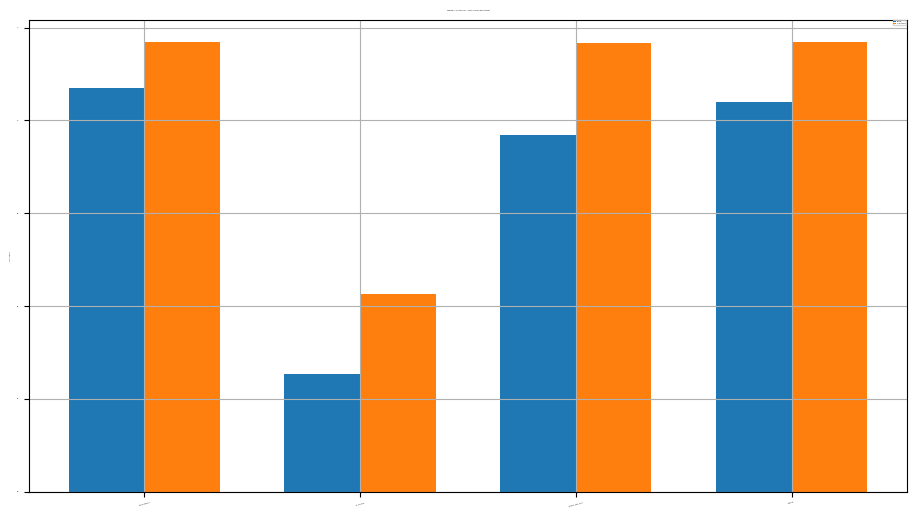

In [18]:
if not comparison_df.empty:
    plot_accuracy_comparison(comparison_df)
else:
    print("⚠️ No comparison data available to plot FedAvg vs Clustered FL.")

# DATASET-LEVEL ACCURACY COMPARISON

📈 Saved accuracy comparison plot to: /users/


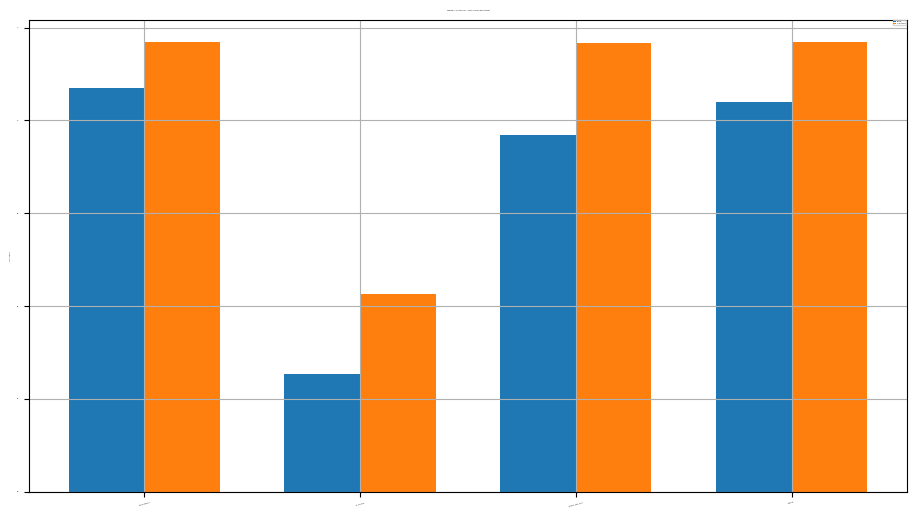

In [19]:
def plot_accuracy_comparison(comparison_df: pd.DataFrame):
    datasets = comparison_df["dataset"].tolist()
    x = np.arange(len(datasets))

    width = 0.35

    fedavg_acc = comparison_df["fedavg_estimated_accuracy"].values
    clust_acc  = comparison_df["best_cluster_accuracy"].values

    plt.figure(figsize=(9, 5))
    plt.bar(x - width/2, fedavg_acc, width, label="FedAvg")
    plt.bar(x + width/2, clust_acc, width, label="Clustered FL")

    plt.xticks(x, datasets, rotation=15)
    plt.ylabel("Test Accuracy")
    plt.title("FedAvg vs Clustered FL — Test Accuracy per Dataset")
    plt.legend()
    plt.tight_layout()

    plot_path = os.path.join(FINAL_RESULTS_DIR, "plot_accuracy_fedavg_vs_clustered.png")
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"📈 Saved accuracy comparison plot to: {plot_path}")
    plt.show()

if not comparison_df.empty:
    plot_accuracy_comparison(comparison_df)
else:
    print("⚠️ No comparison data available to plot FedAvg vs Clustered FL.")

# CLASS-WISE PERFORMANCE OVERVIEW (FEDAVG ONLY, PER DATASET)

📈 Saved class-wise F1 plot for CSE_CIC_IDS2018 to: /users/


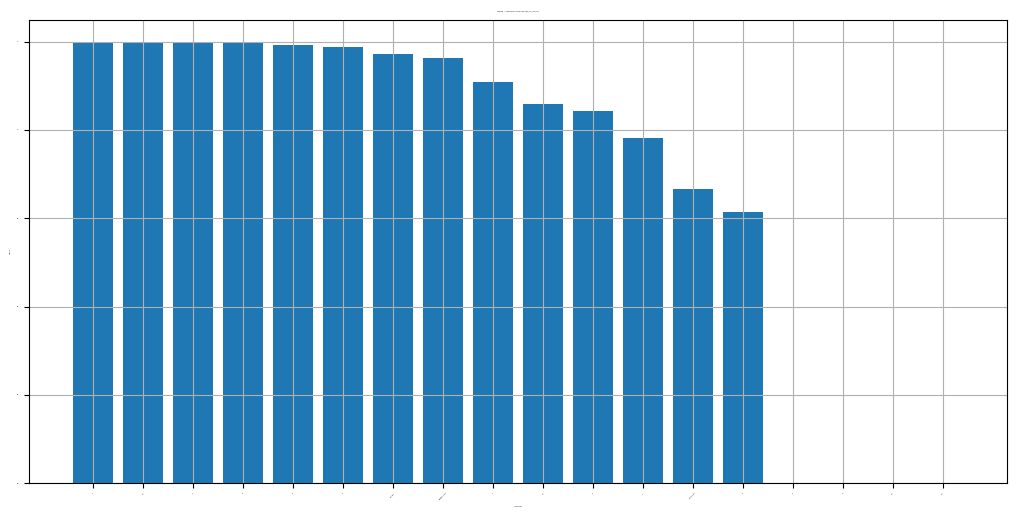

📈 Saved class-wise F1 plot for CSE_CIC_IDS2018 to: /users/


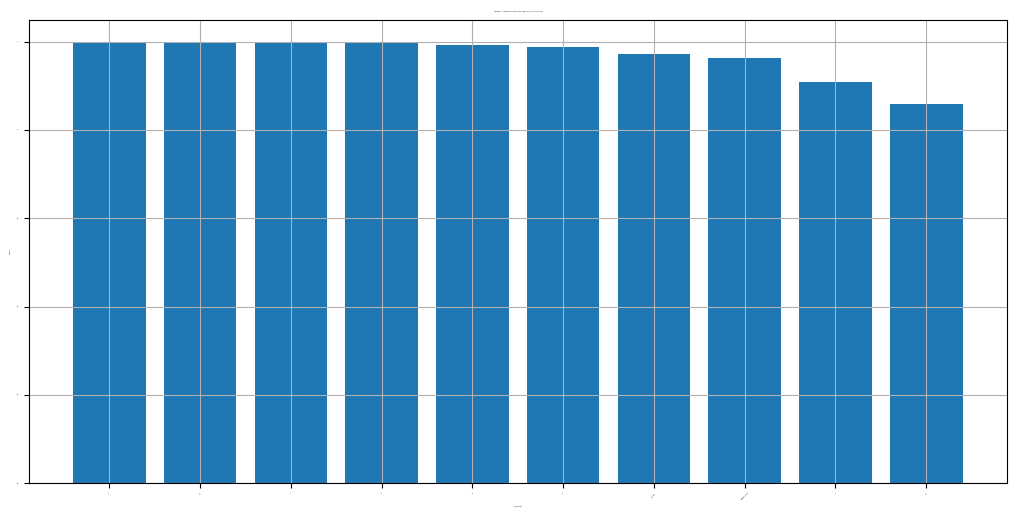

📈 Saved class-wise F1 plot for CIC_IIoT_2025 to: /users/


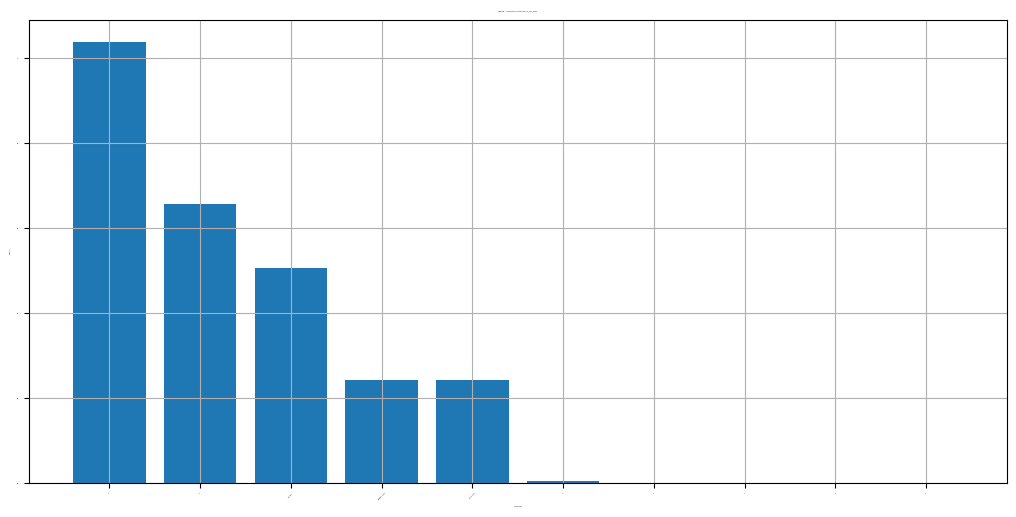

📈 Saved class-wise F1 plot for CIC_IIoT_2025 to: /users/


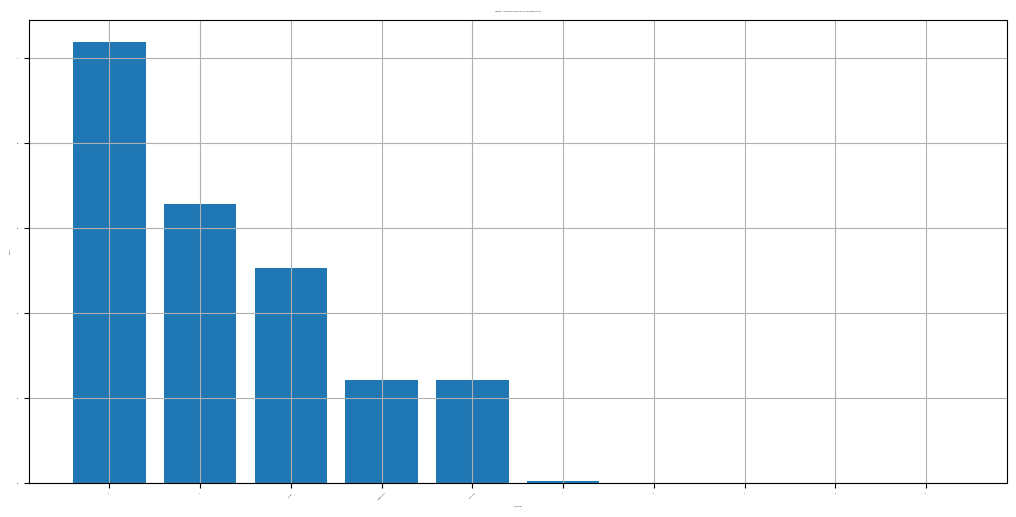

📈 Saved class-wise F1 plot for CIC_BCCC_IoMT_2024 to: /users/


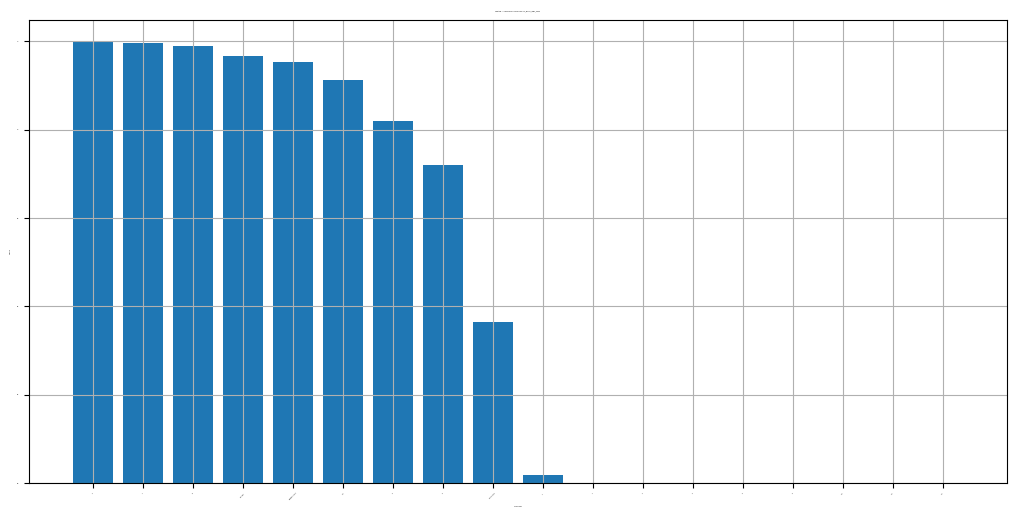

📈 Saved class-wise F1 plot for CIC_BCCC_IoMT_2024 to: /users/


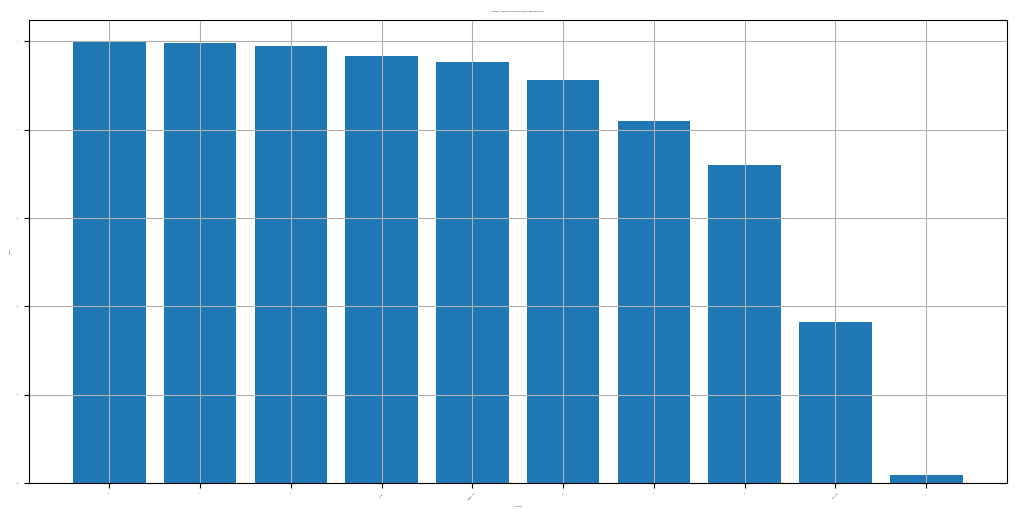

📈 Saved class-wise F1 plot for Combined to: /users/


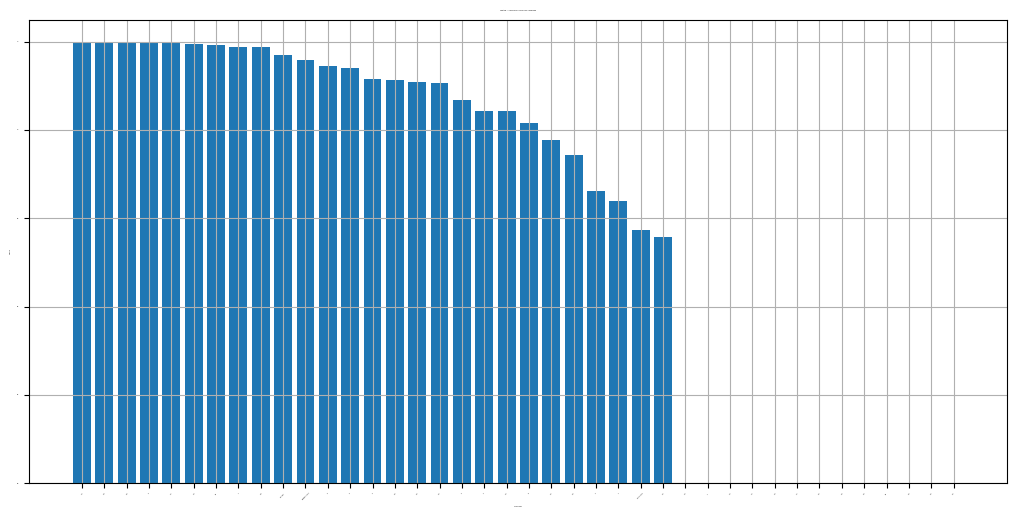

📈 Saved class-wise F1 plot for Combined to: /users/


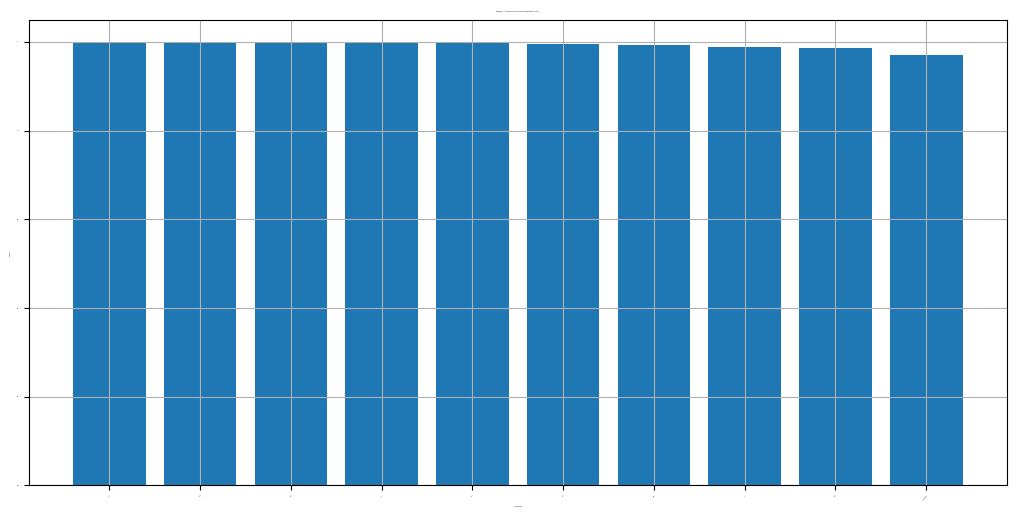

In [20]:
def plot_classwise_f1_for_dataset(df_class: pd.DataFrame, ds_name: str, top_k: int = None):
    df = df_class[df_class["dataset"] == ds_name].copy()
    df = df.sort_values("f1-score", ascending=False)

    if top_k is not None:
        df = df.head(top_k)

    plt.figure(figsize=(10, 5))
    plt.bar(df["class_label"].astype(str), df["f1-score"])
    plt.xlabel("Class Label")
    plt.ylabel("F1-score")
    title_extra = f" (top {top_k})" if top_k is not None else ""
    plt.title(f"FedAvg — Class-wise F1-score on {ds_name}{title_extra}")
    plt.xticks(rotation=45)
    plt.tight_layout()

    file_suffix = f"_top{top_k}" if top_k is not None else ""
    plot_path = os.path.join(
        FINAL_RESULTS_DIR,
        f"fedavg_classwise_f1_{ds_name}{file_suffix}.png"
    )
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"📈 Saved class-wise F1 plot for {ds_name} to: {plot_path}")
    plt.show()

if not fedavg_class_all.empty:
    for ds_name in DATASET_ORDER:
        if ds_name not in fedavg_class_all["dataset"].unique():
            continue
        # Full class-set plot
        plot_classwise_f1_for_dataset(fedavg_class_all, ds_name, top_k=None)
        # Optional: only top 10 classes
        plot_classwise_f1_for_dataset(fedavg_class_all, ds_name, top_k=10)
else:
    print("⚠️ No FedAvg class-wise data available for plotting.")

# OPTIONAL PLACEHOLDER: NON-IID / AGENT-BASED SIMULATION SUMMARY

In [21]:
NONIID_DIR = os.path.join(MODELS_DIR, "NonIID")
noniid_summary_path = os.path.join(NONIID_DIR, "NonIID_summary_all_datasets.csv")

if os.path.exists(noniid_summary_path):
    df_noniid = pd.read_csv(noniid_summary_path)
    print("\n📊 Non-IID / Agent-based Simulation Summary:")
    display(df_noniid)

    # Example: merge Non-IID accuracies into comparison table if columns match
    # Expected columns in df_noniid: dataset, method, test_accuracy, skew_type, skew_level, ...
    # You can customize according to how you save it.
else:
    print("\nℹ️ No Non-IID / Agent-based summary file found yet.")
    print("   When you generate it, save as:")
    print("   ", noniid_summary_path)
    print("   Then you can extend this section to merge into comparison_df.")


ℹ️ No Non-IID / Agent-based summary file found yet.
   When you generate it, save as:
    /users/
   Then you can extend this section to merge into comparison_df.


# FINAL CONSOLIDATED OVERVIEW FOR PAPER

In [22]:
print("\n" + "="*100)
print("✅ FINAL OVERVIEW TABLES CREATED")
print("="*100)
print("1) dataset_split_summary.csv                -> Dataset sizes (train/val/test) & num_classes")
print("2) fedavg_dataset_summary.csv               -> Dataset-wise FedAvg performance")
print("3) fedavg_classwise_all_datasets.csv        -> Class-wise FedAvg performance (per dataset)")
print("4) clustered_dataset_summary.csv            -> Dataset-wise Clustered FL performance")
print("5) clustered_clusterwise_all_datasets.csv   -> Cluster-wise performance")
print("6) comparison_fedavg_vs_clustered.csv       -> Main comparison table for paper")
print("7) Plots (PNG) under final_results/:")
print("     - plot_accuracy_fedavg_vs_clustered.png")
print("     - fedavg_classwise_f1_<dataset>.png")
print("\nUse these directly in your SCI-level paper: Results, Discussion & Ablation sections.")


✅ FINAL OVERVIEW TABLES CREATED
1) dataset_split_summary.csv                -> Dataset sizes (train/val/test) & num_classes
2) fedavg_dataset_summary.csv               -> Dataset-wise FedAvg performance
3) fedavg_classwise_all_datasets.csv        -> Class-wise FedAvg performance (per dataset)
4) clustered_dataset_summary.csv            -> Dataset-wise Clustered FL performance
5) clustered_clusterwise_all_datasets.csv   -> Cluster-wise performance
6) comparison_fedavg_vs_clustered.csv       -> Main comparison table for paper
7) Plots (PNG) under final_results/:
     - plot_accuracy_fedavg_vs_clustered.png
     - fedavg_classwise_f1_<dataset>.png

Use these directly in your SCI-level paper: Results, Discussion & Ablation sections.
